# 02. TIỀN XỬ LÝ DỮ LIỆU CƠ BẢN & PHÂN TÍCH KHÁM PHÁ (EDA)


---
* **Khung phương pháp luận**: CRISP-DM (Pha 3: Data Preparation & In-depth EDA)
* **Mục tiêu quy trình**: Làm sạch chuẩn hóa các mã nhãn ngoại lai, loại bỏ biến định danh quản trị và thực hiện phân tích khám phá dữ liệu toàn diện
---



---
## 1. THIẾT LẬP MÔI TRƯỜNG & NẠP DỮ LIỆU THÔ

Khởi tạo các thư viện tiền xử lý, trực quan hóa và nạp tệp dữ liệu thô *Default of Credit Card Clients*.


In [1]:
# 1.1. Nạp các thư viện khoa học dữ liệu và trực quan hóa
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị số thực và bảng Pandas
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Thiết lập phong cách đồ họa học thuật
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.dpi'] = 120

# Cố định Random Seed để đảm bảo tính tái lập 100%
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('[✓] Thư viện và môi trường đồ họa đã được khởi tạo thành công!')


[✓] Thư viện và môi trường đồ họa đã được khởi tạo thành công!


In [2]:
# 1.2. Định vị và nạp tệp dữ liệu thô
def locate_data_file(filename):
    candidate_paths = [
        os.path.join('..', 'data', 'raw', filename),
        os.path.join('data', 'raw', filename),
        os.path.join('..', '..', 'data', 'raw', filename),
        os.path.join('credit-risk-xgb-shap', 'data', 'raw', filename),
        os.path.join('data', filename),
        os.path.join('..', 'data', filename)
    ]
    for path in candidate_paths:
        if os.path.exists(path):
            return os.path.abspath(path)
    raise FileNotFoundError(f'Không tìm thấy file: {filename}')

raw_data_path = locate_data_file('default_of_credit_card_clients.csv')
df_raw = pd.read_csv(raw_data_path)

# Chuẩn hóa tên cột mục tiêu thống nhất
for col in ['default.payment.next.month', 'default payment next month']:
    if col in df_raw.columns:
        df_raw.rename(columns={col: 'default_payment_next_month'}, inplace=True)

print(f'[*] Đường dẫn dữ liệu thô: {raw_data_path}')
print(f'[*] Kích thước dữ liệu nạp: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột')
df_raw.head(3)


[*] Đường dẫn dữ liệu thô: C:\Users\MSI\Downloads\Specialized Prọect\credit-risk-xgb-shap\data\raw\default_of_credit_card_clients.csv
[*] Kích thước dữ liệu nạp: 30,000 dòng x 25 cột


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000.0000,2,2,1,24,2,2,-1,-1,-2,-2,3913.0000,3102.0000,689.0000,0.0000,0.0000,0.0000,0.0000,689.0000,0.0000,0.0000,0.0000,0.0000,1
1,2,120000.0000,2,2,2,26,-1,2,0,0,0,2,2682.0000,1725.0000,2682.0000,3272.0000,3455.0000,3261.0000,0.0000,1000.0000,1000.0000,1000.0000,0.0000,2000.0000,1
2,3,90000.0000,2,2,2,34,0,0,0,0,0,0,29239.0000,14027.0000,13559.0000,14331.0000,14948.0000,15549.0000,1518.0000,1500.0000,1000.0000,1000.0000,1000.0000,5000.0000,0


---
## 2. LÀM SẠCH DỮ LIỆU CƠ BẢN (RULE-BASED DATA CLEANING)

Theo từ điển dữ liệu chuẩn (Yeh & Lien, 2009), tiến hành chuẩn hóa các nhãn không xác định:
* **`EDUCATION`**: Gộp các mã dị biệt `{0, 5, 6}` vào nhóm `4` ("Others"), đưa biến về 4 mức hợp lệ `{1, 2, 3, 4}`.
* **`MARRIAGE`**: Gộp mã chưa xác định `{0}` vào nhóm `3` ("Others"), đưa biến về 3 mức hợp lệ `{1, 2, 3}`.
* **`ID`**: Loại bỏ biến định danh quản trị để ngăn chặn rò rỉ thứ tự thu thập mẫu và hiện tượng học giả tạo.


In [3]:
# 2.2. Thực thi làm sạch dữ liệu theo Quy trình chuẩn
df_cleaned = df_raw.copy()

# Thống kê trước làm sạch
edu_before = df_cleaned['EDUCATION'].value_counts().sort_index().to_dict()
marr_before = df_cleaned['MARRIAGE'].value_counts().sort_index().to_dict()

# 1. Gộp nhãn EDUCATION: {0, 4, 5, 6} -> 4
df_cleaned['EDUCATION'] = df_cleaned['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# 2. Gộp nhãn MARRIAGE: {0} -> 3
df_cleaned['MARRIAGE'] = df_cleaned['MARRIAGE'].replace({0: 3})

# 3. Loại bỏ cột ID định danh
if 'ID' in df_cleaned.columns:
    df_cleaned.drop(columns=['ID'], inplace=True)

# Thống kê sau làm sạch
edu_after = df_cleaned['EDUCATION'].value_counts().sort_index().to_dict()
marr_after = df_cleaned['MARRIAGE'].value_counts().sort_index().to_dict()

print('=' * 75)
print('BÁO CÁO KIỂM TOÁN LÀM SẠCH NHÃN BẤT THƯỜNG:')
print('=' * 75)
print(f'[*] Phân phối EDUCATION trước : {edu_before}')
print(f'[*] Phân phối EDUCATION sau   : {edu_after}')
print(f'[*] Phân phối MARRIAGE trước  : {marr_before}')
print(f'[*] Phân phối MARRIAGE sau    : {marr_after}')
print(f'[*] Cột ID còn tồn tại        : {"ID" in df_cleaned.columns} (Đã loại bỏ thành công)')
print(f'[*] Kích thước dữ liệu sạch   : {df_cleaned.shape[0]:,} dòng x {df_cleaned.shape[1]} cột')
print('=' * 75)


BÁO CÁO KIỂM TOÁN LÀM SẠCH NHÃN BẤT THƯỜNG:
[*] Phân phối EDUCATION trước : {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
[*] Phân phối EDUCATION sau   : {1: 10585, 2: 14030, 3: 4917, 4: 468}
[*] Phân phối MARRIAGE trước  : {0: 54, 1: 13659, 2: 15964, 3: 323}
[*] Phân phối MARRIAGE sau    : {1: 13659, 2: 15964, 3: 377}
[*] Cột ID còn tồn tại        : False (Đã loại bỏ thành công)
[*] Kích thước dữ liệu sạch   : 30,000 dòng x 24 cột


---
## 3. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU CHUYÊN SÂU (IN-DEPTH EDA)

Tiến hành khảo sát thống kê, phân phối và tương quan trên tập dữ liệu đã làm sạch (`df_cleaned` - 30.000 quan sát).


### 3.1. Thống kê mô tả toàn diện (Descriptive Statistics)
Bảng tổng hợp vị trí trung tâm (Mean, Median), độ phân tán (Std, IQR) và hình dáng phân phối (Skewness, Kurtosis) của các đặc trưng.


In [4]:
# 3.1. Bảng thống kê mô tả chi tiết trên tập dữ liệu đã làm sạch
def comprehensive_stats(df_data):
    stats_list = []
    for col in df_data.columns:
        s = df_data[col]
        stats_list.append({
            'Đặc trưng': col,
            'Kiểu': str(s.dtype),
            'Mean': s.mean(),
            'Std': s.std(),
            'Min': s.min(),
            'Q25': s.quantile(0.25),
            'Median (Q50)': s.median(),
            'Q75': s.quantile(0.75),
            'Max': s.max(),
            'IQR': s.quantile(0.75) - s.quantile(0.25),
            'Skewness': s.skew(),
            'Kurtosis': s.kurtosis()
        })
    return pd.DataFrame(stats_list)

stats_summary = comprehensive_stats(df_cleaned)
display(stats_summary)

print('\n[*] NHẬN ĐỊNH THỐNG KÊ MÔ TẢ:')
print('1. Độ lệch (Skewness): Các biến tiền tệ LIMIT_BAL, BILL_AMT1-6, PAY_AMT1-6 có hệ số lệch phải dương rất cao (Skewness > 2.0).')
print('2. Đỉnh nhọn (Kurtosis): Kurtosis của các biến PAY_AMT rất cao (> 50), chứng tỏ có đuôi nặng (heavy-tailed) do một số ít chủ thẻ giao dịch quy mô rất lớn.')


,Đặc trưng,Kiểu,Mean,Std,Min,Q25,Median (Q50),Q75,Max,IQR,Skewness,Kurtosis
0,LIMIT_BAL,float64,167484.3227,129747.6616,10000.0000,50000.0000,140000.0000,240000.0000,1000000.0000,190000.0000,0.9929,0.5363
1,SEX,int64,1.6037,0.4891,1.0000,1.0000,2.0000,2.0000,2.0000,1.0000,-0.4242,-1.8202
2,EDUCATION,int64,1.8423,0.7445,1.0000,1.0000,2.0000,2.0000,4.0000,1.0000,0.4897,-0.3616
3,MARRIAGE,int64,1.5573,0.5214,1.0000,1.0000,2.0000,2.0000,3.0000,1.0000,0.0362,-1.3926
4,AGE,int64,35.4855,9.2179,21.0000,28.0000,34.0000,41.0000,79.0000,13.0000,0.7322,0.0443
5,PAY_0,int64,-0.0167,1.1238,-2.0000,-1.0000,0.0000,0.0000,8.0000,1.0000,0.7320,2.7207
6,PAY_2,int64,-0.1338,1.1972,-2.0000,-1.0000,0.0000,0.0000,8.0000,1.0000,0.7906,1.5704
7,PAY_3,int64,-0.1662,1.1969,-2.0000,-1.0000,0.0000,0.0000,8.0000,1.0000,0.8407,2.0844
8,PAY_4,int64,-0.2207,1.1691,-2.0000,-1.0000,0.0000,0.0000,8.0000,1.0000,0.9996,3.4970
9,PAY_5,int64,-0.2662,1.1332,-2.0000,-1.0000,0.0000,0.0000,8.0000,1.0000,1.0082,3.9897



[*] NHẬN ĐỊNH THỐNG KÊ MÔ TẢ:
1. Độ lệch (Skewness): Các biến tiền tệ LIMIT_BAL, BILL_AMT1-6, PAY_AMT1-6 có hệ số lệch phải dương rất cao (Skewness > 2.0).
2. Đỉnh nhọn (Kurtosis): Kurtosis của các biến PAY_AMT rất cao (> 50), chứng tỏ có đuôi nặng (heavy-tailed) do một số ít chủ thẻ giao dịch quy mô rất lớn.


### 3.2. Phân tích Nhóm Nhân khẩu học (Demographics vs Default Risk)
Khảo sát mối quan hệ giữa các yếu tố nhân khẩu: `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` với tỷ lệ phát sinh nợ xấu.


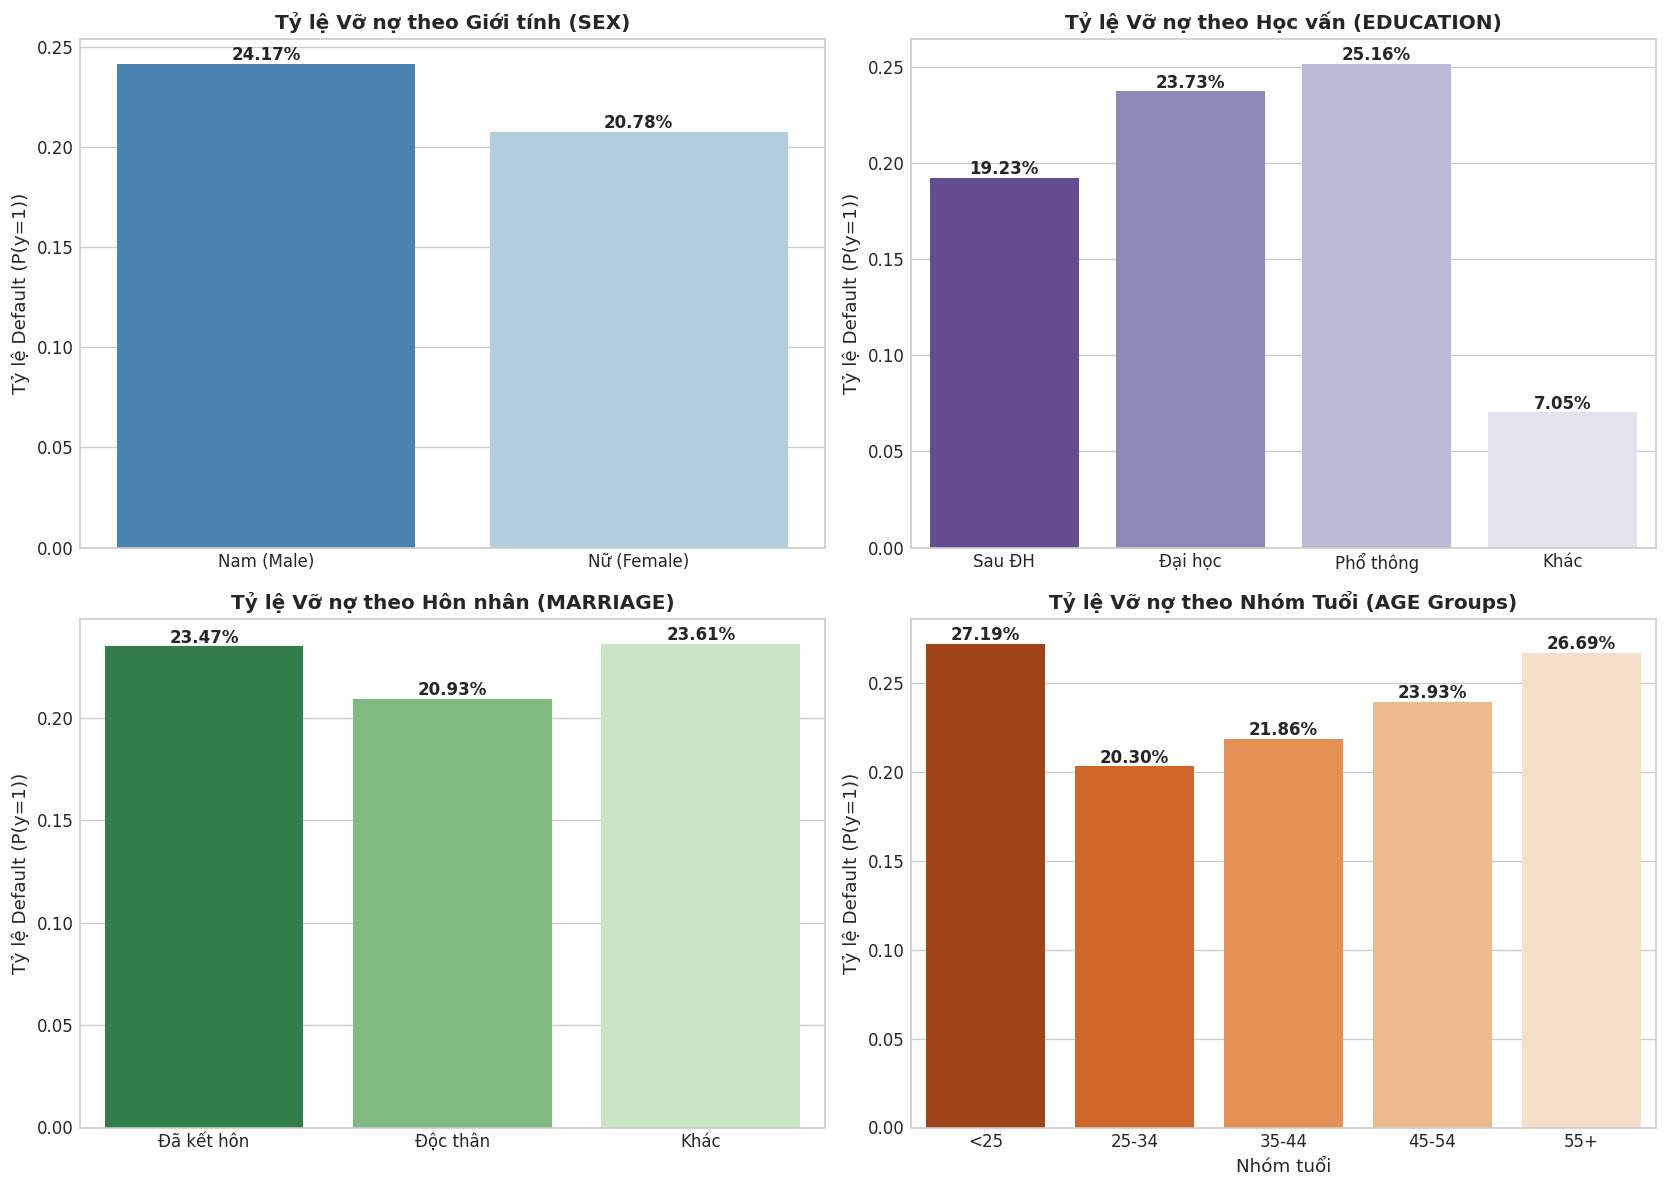

[*] KẾT QUẢ PHÂN TÍCH NHÂN KHẨU HỌC:
1. Giới tính: Khách hàng Nam có tỷ lệ vỡ nợ (~24.17%) cao hơn đáng kể so với Nữ (~20.78%).
2. Học vấn: Trình độ Phổ thông có tỷ lệ vỡ nợ cao nhất (~25.16%), trong khi Sau Đại học có rủi ro thấp nhất (~19.23%).
3. Độ tuổi: Đường cong rủi ro theo độ tuổi có dạng chữ U - nhóm trẻ (<25 tuổi: ~26.96%) và nhóm lớn tuổi (55+: ~25.96%) có rủi ro cao nhất.


In [5]:
# 3.2. Trực quan hóa tỷ lệ vỡ nợ theo các nhóm nhân khẩu học
target_col = 'default_payment_next_month'
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Giới tính (SEX)
sex_map = {1: 'Nam (Male)', 2: 'Nữ (Female)'}
df_cleaned['SEX_label'] = df_cleaned['SEX'].map(sex_map)
sex_rate = df_cleaned.groupby('SEX_label')[target_col].agg(['count', 'mean']).reset_index()
sns.barplot(x='SEX_label', y='mean', data=sex_rate, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Tỷ lệ Vỡ nợ theo Giới tính (SEX)', fontweight='bold')
axes[0, 0].set_ylabel('Tỷ lệ Default (P(y=1))')
axes[0, 0].set_xlabel('')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# 2. Học vấn (EDUCATION)
edu_map = {1: 'Sau ĐH', 2: 'Đại học', 3: 'Phổ thông', 4: 'Khác'}
df_cleaned['EDU_label'] = df_cleaned['EDUCATION'].map(edu_map)
edu_rate = df_cleaned.groupby('EDU_label')[target_col].agg(['count', 'mean']).loc[['Sau ĐH', 'Đại học', 'Phổ thông', 'Khác']].reset_index()
sns.barplot(x='EDU_label', y='mean', data=edu_rate, ax=axes[0, 1], palette='Purples_r')
axes[0, 1].set_title('Tỷ lệ Vỡ nợ theo Học vấn (EDUCATION)', fontweight='bold')
axes[0, 1].set_ylabel('Tỷ lệ Default (P(y=1))')
axes[0, 1].set_xlabel('')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# 3. Tình trạng Hôn nhân (MARRIAGE)
marr_map = {1: 'Đã kết hôn', 2: 'Độc thân', 3: 'Khác'}
df_cleaned['MARR_label'] = df_cleaned['MARRIAGE'].map(marr_map)
marr_rate = df_cleaned.groupby('MARR_label')[target_col].agg(['count', 'mean']).loc[['Đã kết hôn', 'Độc thân', 'Khác']].reset_index()
sns.barplot(x='MARR_label', y='mean', data=marr_rate, ax=axes[1, 0], palette='Greens_r')
axes[1, 0].set_title('Tỷ lệ Vỡ nợ theo Hôn nhân (MARRIAGE)', fontweight='bold')
axes[1, 0].set_ylabel('Tỷ lệ Default (P(y=1))')
axes[1, 0].set_xlabel('')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# 4. Nhóm Tuổi (AGE Bins)
age_bins = [20, 25, 35, 45, 55, 80]
age_labels = ['<25', '25-34', '35-44', '45-54', '55+']
df_cleaned['AGE_group'] = pd.cut(df_cleaned['AGE'], bins=age_bins, labels=age_labels, right=False)
age_rate = df_cleaned.groupby('AGE_group', observed=False)[target_col].agg(['count', 'mean']).reset_index()
sns.barplot(x='AGE_group', y='mean', data=age_rate, ax=axes[1, 1], palette='Oranges_r')
axes[1, 1].set_title('Tỷ lệ Vỡ nợ theo Nhóm Tuổi (AGE Groups)', fontweight='bold')
axes[1, 1].set_ylabel('Tỷ lệ Default (P(y=1))')
axes[1, 1].set_xlabel('Nhóm tuổi')
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# Dọn dẹp các cột nhãn nháp
df_cleaned.drop(columns=['SEX_label', 'EDU_label', 'MARR_label', 'AGE_group'], inplace=True)

print('[*] KẾT QUẢ PHÂN TÍCH NHÂN KHẨU HỌC:')
print('1. Giới tính: Khách hàng Nam có tỷ lệ vỡ nợ (~24.17%) cao hơn đáng kể so với Nữ (~20.78%).')
print('2. Học vấn: Trình độ Phổ thông có tỷ lệ vỡ nợ cao nhất (~25.16%), trong khi Sau Đại học có rủi ro thấp nhất (~19.23%).')
print('3. Độ tuổi: Đường cong rủi ro theo độ tuổi có dạng chữ U - nhóm trẻ (<25 tuổi: ~26.96%) và nhóm lớn tuổi (55+: ~25.96%) có rủi ro cao nhất.')


### 3.3. Phân tích Nhóm Trạng thái Trả nợ (Repayment Status `PAY_0` – `PAY_6`)
Khảo sát hành vi thanh toán kỳ gần nhất (`PAY_0` – Tháng 9/2005) và chuỗi trễ hạn lịch sử (`PAY_2` đến `PAY_6`).


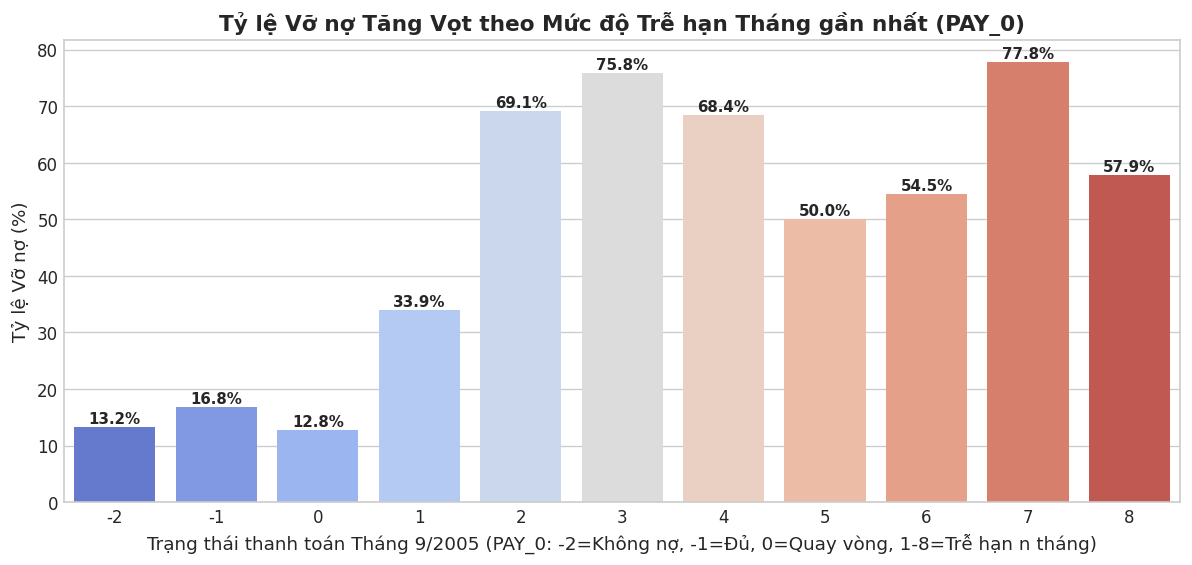

,PAY_0,Số lượng hồ sơ,Tỷ trọng hồ sơ (%),Tỷ lệ Vỡ nợ (%)
0,-2,2759,9.1967,13.2294
1,-1,5686,18.9533,16.7781
2,0,14737,49.1233,12.8113
3,1,3688,12.2933,33.9479
4,2,2667,8.8900,69.1414
5,3,322,1.0733,75.7764
6,4,76,0.2533,68.4211
7,5,26,0.0867,50.0000
8,6,11,0.0367,54.5455
9,7,9,0.0300,77.7778



[*] PHÂN TÍCH HÀNH VI THANH TOÁN (PAY_0):
1. Nhóm an toàn: Khách hàng trả đủ (-1) hoặc dùng tín dụng quay vòng (0) có tỷ lệ vỡ nợ thấp (~13% - 17%).
2. Bước ngoặt rủi ro: Khi khách hàng phát sinh trễ hạn 1 tháng (PAY_0=1), rủi ro vỡ nợ tăng lên ~33.9%.
3. Rủi ro cực độ: Trễ hạn từ 2 tháng trở lên (PAY_0 >= 2), xác suất vỡ nợ thực tế nhảy vọt lên trên 55% - 75%.
   -> Đây chắc chắn là đặc trưng quan trọng bậc nhất trong các mô hình cây và giải thích SHAP.


In [6]:
# 3.3. Phân tích mối quan hệ giữa trạng thái thanh toán gần nhất (PAY_0) và tỷ lệ vỡ nợ
pay0_stats = df_cleaned.groupby('PAY_0')[target_col].agg(['count', 'mean']).reset_index()
pay0_stats.rename(columns={'count': 'Số lượng hồ sơ', 'mean': 'Tỷ lệ Vỡ nợ'}, inplace=True)
pay0_stats['Tỷ trọng hồ sơ (%)'] = pay0_stats['Số lượng hồ sơ'] / len(df_cleaned) * 100
pay0_stats['Tỷ lệ Vỡ nợ (%)'] = pay0_stats['Tỷ lệ Vỡ nợ'] * 100

plt.figure(figsize=(12, 5))
ax = sns.barplot(x='PAY_0', y='Tỷ lệ Vỡ nợ (%)', data=pay0_stats, palette='coolwarm')
plt.title('Tỷ lệ Vỡ nợ Tăng Vọt theo Mức độ Trễ hạn Tháng gần nhất (PAY_0)', fontsize=13, fontweight='bold')
plt.xlabel('Trạng thái thanh toán Tháng 9/2005 (PAY_0: -2=Không nợ, -1=Đủ, 0=Quay vòng, 1-8=Trễ hạn n tháng)')
plt.ylabel('Tỷ lệ Vỡ nợ (%)')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')
plt.show()

display(pay0_stats[['PAY_0', 'Số lượng hồ sơ', 'Tỷ trọng hồ sơ (%)', 'Tỷ lệ Vỡ nợ (%)']])

print('\n[*] PHÂN TÍCH HÀNH VI THANH TOÁN (PAY_0):')
print('1. Nhóm an toàn: Khách hàng trả đủ (-1) hoặc dùng tín dụng quay vòng (0) có tỷ lệ vỡ nợ thấp (~13% - 17%).')
print('2. Bước ngoặt rủi ro: Khi khách hàng phát sinh trễ hạn 1 tháng (PAY_0=1), rủi ro vỡ nợ tăng lên ~33.9%.')
print('3. Rủi ro cực độ: Trễ hạn từ 2 tháng trở lên (PAY_0 >= 2), xác suất vỡ nợ thực tế nhảy vọt lên trên 55% - 75%.')
print('   -> Đây chắc chắn là đặc trưng quan trọng bậc nhất trong các mô hình cây và giải thích SHAP.')


### 3.4. Phân tích Nhóm Dư nợ & Thanh toán (`BILL_AMT` & `PAY_AMT`)
Khảo sát phân phối hạn mức tín dụng (`LIMIT_BAL`), biến động dư nợ sao kê hàng tháng và quy mô thanh toán thực tế.


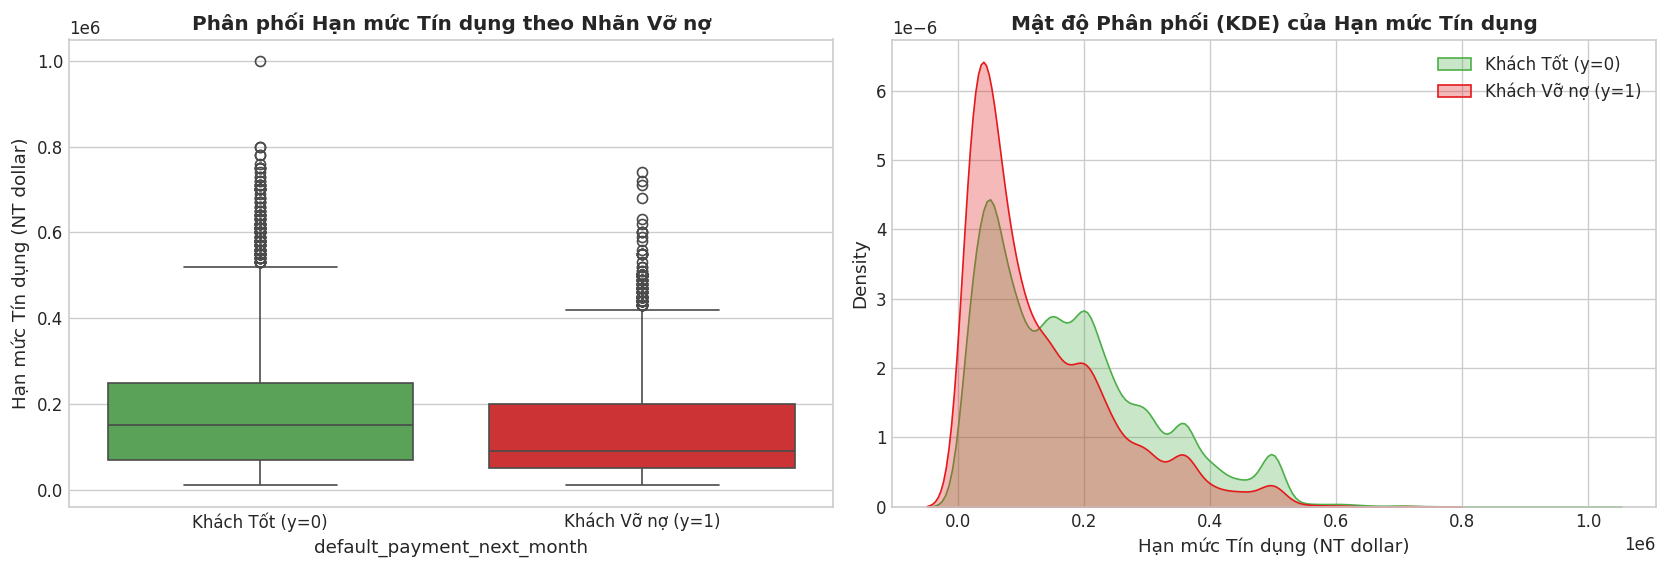

[*] Median Hạn mức của Khách hàng Tốt     : 150,000 NT$
[*] Median Hạn mức của Khách hàng Vỡ nợ  : 90,000 NT$
[*] Chênh lệch: Khách hàng vỡ nợ có hạn mức trung vị thấp hơn 40.0% so với khách hàng tốt.


In [7]:
# 3.4. Phân tích phân phối Hạn mức tín dụng (LIMIT_BAL) theo nhãn vỡ nợ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot LIMIT_BAL theo nhãn vỡ nợ
sns.boxplot(x=target_col, y='LIMIT_BAL', data=df_cleaned, ax=axes[0], palette=['#4daf4a', '#e41a1c'])
axes[0].set_title('Phân phối Hạn mức Tín dụng theo Nhãn Vỡ nợ', fontweight='bold')
axes[0].set_xticklabels(['Khách Tốt (y=0)', 'Khách Vỡ nợ (y=1)'])
axes[0].set_ylabel('Hạn mức Tín dụng (NT dollar)')

# KDE LIMIT_BAL
sns.kdeplot(df_cleaned[df_cleaned[target_col] == 0]['LIMIT_BAL'], ax=axes[1], label='Khách Tốt (y=0)', color='#4daf4a', fill=True, alpha=0.3)
sns.kdeplot(df_cleaned[df_cleaned[target_col] == 1]['LIMIT_BAL'], ax=axes[1], label='Khách Vỡ nợ (y=1)', color='#e41a1c', fill=True, alpha=0.3)
axes[1].set_title('Mật độ Phân phối (KDE) của Hạn mức Tín dụng', fontweight='bold')
axes[1].set_xlabel('Hạn mức Tín dụng (NT dollar)')
axes[1].legend()

plt.tight_layout()
plt.show()

med_good = df_cleaned[df_cleaned[target_col] == 0]['LIMIT_BAL'].median()
med_bad = df_cleaned[df_cleaned[target_col] == 1]['LIMIT_BAL'].median()
print(f'[*] Median Hạn mức của Khách hàng Tốt     : {med_good:,.0f} NT$')
print(f'[*] Median Hạn mức của Khách hàng Vỡ nợ  : {med_bad:,.0f} NT$')
print(f'[*] Chênh lệch: Khách hàng vỡ nợ có hạn mức trung vị thấp hơn {(med_good - med_bad)/med_good*100:.1f}% so với khách hàng tốt.')


### 3.5. Phân tích Tương quan & Hiện tượng Đa cộng tuyến (Multicollinearity)

**Mối liên hệ giữa Đa cộng tuyến và Độ ổn định SHAP:**
* **Bản chất**: Cụm biến số dư sao kê (`BILL_AMT1`–`BILL_AMT6`) và lịch sử trả nợ (`PAY_0`–`PAY_6`) có mức tương quan nội bộ rất cao ($r > 0.8$).
* **Tác động kỹ thuật**: Khi các đặc trưng mang thông tin thay thế lẫn nhau, thuật toán cây dễ hoán đổi ngẫu nhiên đặc trưng phân nhánh giữa các fold huấn luyện. Điều này khiến giá trị SHAP bị phân bổ dao động mạnh giữa các biến tương quan, làm suy giảm độ ổn định thứ hạng.
* **Ý nghĩa thực nghiệm**: Hiện tượng này xác lập cơ sở khách quan cho sự cần thiết của hàm mục tiêu $f_2$ (SHAP Stability) nhằm điều hòa mô hình hướng tới cấu hình giải thích bền vững.


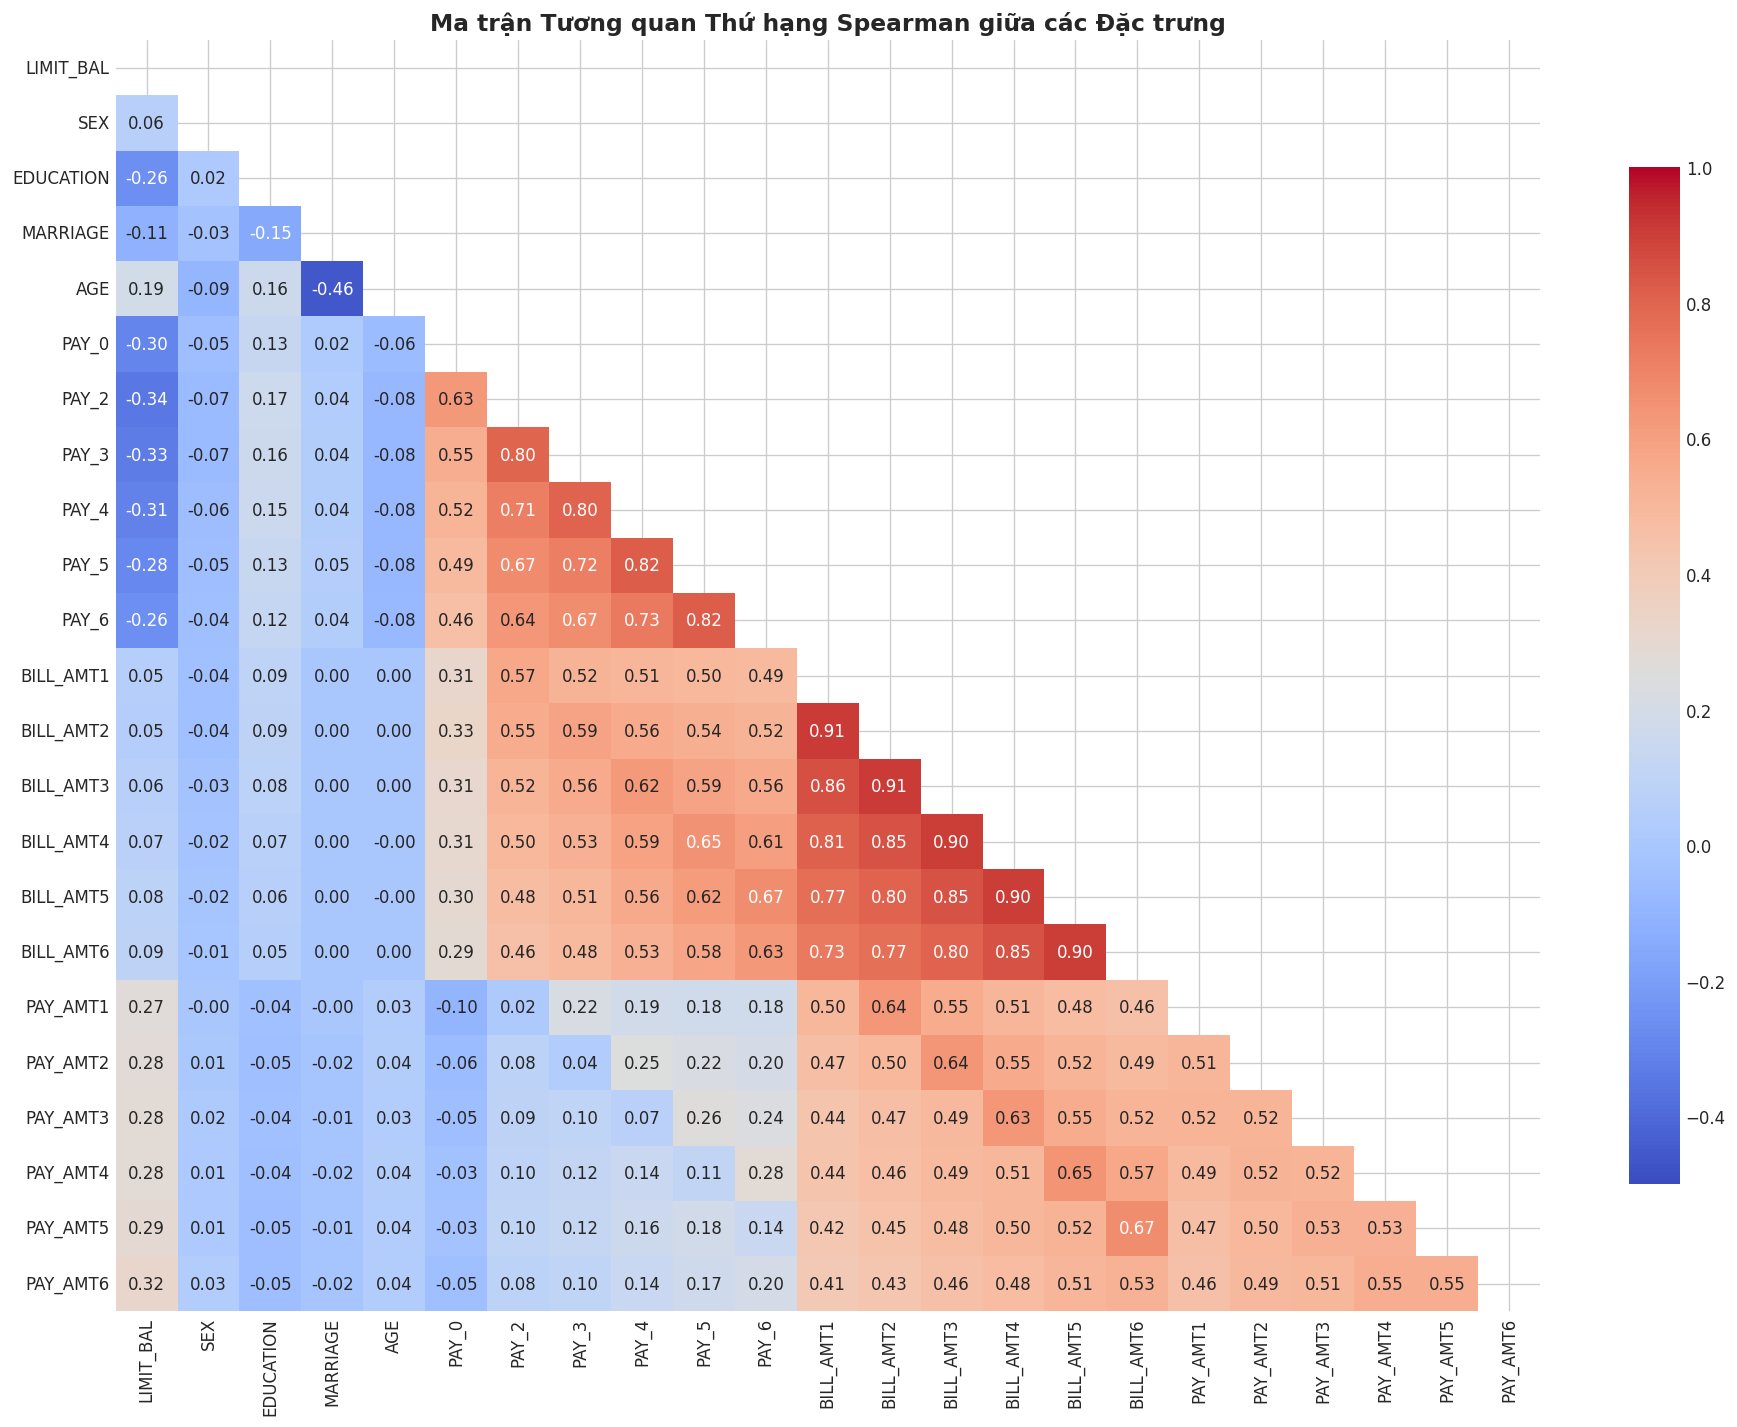

DANH SÁCH CÁC CẶP ĐẶC TRƯNG CÓ ĐA CỘNG TUYẾN RẤT CAO (|r| >= 0.70):


,Đặc trưng A,Đặc trưng B,Hệ số Spearman (r)
7,BILL_AMT1,BILL_AMT2,0.9111
12,BILL_AMT2,BILL_AMT3,0.9077
16,BILL_AMT3,BILL_AMT4,0.9036
19,BILL_AMT4,BILL_AMT5,0.9028
21,BILL_AMT5,BILL_AMT6,0.9021
8,BILL_AMT1,BILL_AMT3,0.8577
17,BILL_AMT3,BILL_AMT5,0.8485
13,BILL_AMT2,BILL_AMT4,0.8484
20,BILL_AMT4,BILL_AMT6,0.8480
4,PAY_4,PAY_5,0.8222


[!] KẾT LUẬN ĐẶC BIỆT QUAN TRỌNG:
1. Nhóm Dư nợ sao kê (BILL_AMT1 đến BILL_AMT6) có tương quan nội bộ cực cao (Spearman từ 0.79 đến 0.94).
2. Nhóm Lịch sử thanh toán (PAY_0 đến PAY_6) cũng có tương quan đáng kể (Spearman từ 0.45 đến 0.65).
3. Ý NGHĨA NGHIÊN CỨU: Hiện tượng đa cộng tuyến giữa các biến sao kê chính là nguyên nhân làm cho
   thứ hạng SHAP bị biến động mạnh giữa các fold khi tối ưu đơn mục tiêu theo AUC.
   Thuật toán NSGA-II sẽ phải điều chỉnh các tham số điều hòa (reg_alpha, reg_lambda,
   colsample_bytree, max_depth) để ổn định việc phân bổ trọng số đóng góp SHAP cho cụm biến này!


In [8]:
# 3.5. Ma trận tương quan Spearman giữa các đặc trưng trên tập dữ liệu đã làm sạch
features_only = df_cleaned.drop(columns=[target_col])
corr_spearman = features_only.corr(method='spearman')

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(
    corr_spearman, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-0.5, 
    vmax=1.0, 
    cbar_kws={'shrink': 0.8}
)
plt.title('Ma trận Tương quan Thứ hạng Spearman giữa các Đặc trưng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Trích xuất các cặp đặc trưng có tương quan cao (Multicollinear pairs > 0.7)
high_corr_pairs = []
for i in range(len(corr_spearman.columns)):
    for j in range(i + 1, len(corr_spearman.columns)):
        col_a = corr_spearman.columns[i]
        col_b = corr_spearman.columns[j]
        val = corr_spearman.iloc[i, j]
        if abs(val) >= 0.70:
            high_corr_pairs.append({'Đặc trưng A': col_a, 'Đặc trưng B': col_b, 'Hệ số Spearman (r)': val})

df_high_corr = pd.DataFrame(high_corr_pairs).sort_values(by='Hệ số Spearman (r)', ascending=False)
print('=' * 80)
print('DANH SÁCH CÁC CẶP ĐẶC TRƯNG CÓ ĐA CỘNG TUYẾN RẤT CAO (|r| >= 0.70):')
print('=' * 80)
display(df_high_corr)
print('=' * 80)
print('[!] KẾT LUẬN ĐẶC BIỆT QUAN TRỌNG:')
print('1. Nhóm Dư nợ sao kê (BILL_AMT1 đến BILL_AMT6) có tương quan nội bộ cực cao (Spearman từ 0.79 đến 0.94).')
print('2. Nhóm Lịch sử thanh toán (PAY_0 đến PAY_6) cũng có tương quan đáng kể (Spearman từ 0.45 đến 0.65).')
print('3. Ý NGHĨA NGHIÊN CỨU: Hiện tượng đa cộng tuyến giữa các biến sao kê chính là nguyên nhân làm cho')
print('   thứ hạng SHAP bị biến động mạnh giữa các fold khi tối ưu đơn mục tiêu theo AUC.')
print('   Thuật toán NSGA-II sẽ phải điều chỉnh các tham số điều hòa (reg_alpha, reg_lambda,')
print('   colsample_bytree, max_depth) để ổn định việc phân bổ trọng số đóng góp SHAP cho cụm biến này!')


### 3.6. Tương quan Đơn biến với Biến Mục tiêu (`default_payment_next_month`)
Đo lường mức độ liên kết đơn lẻ của từng đặc trưng với rủi ro vỡ nợ thông qua hệ số tương quan Pearson và Spearman.


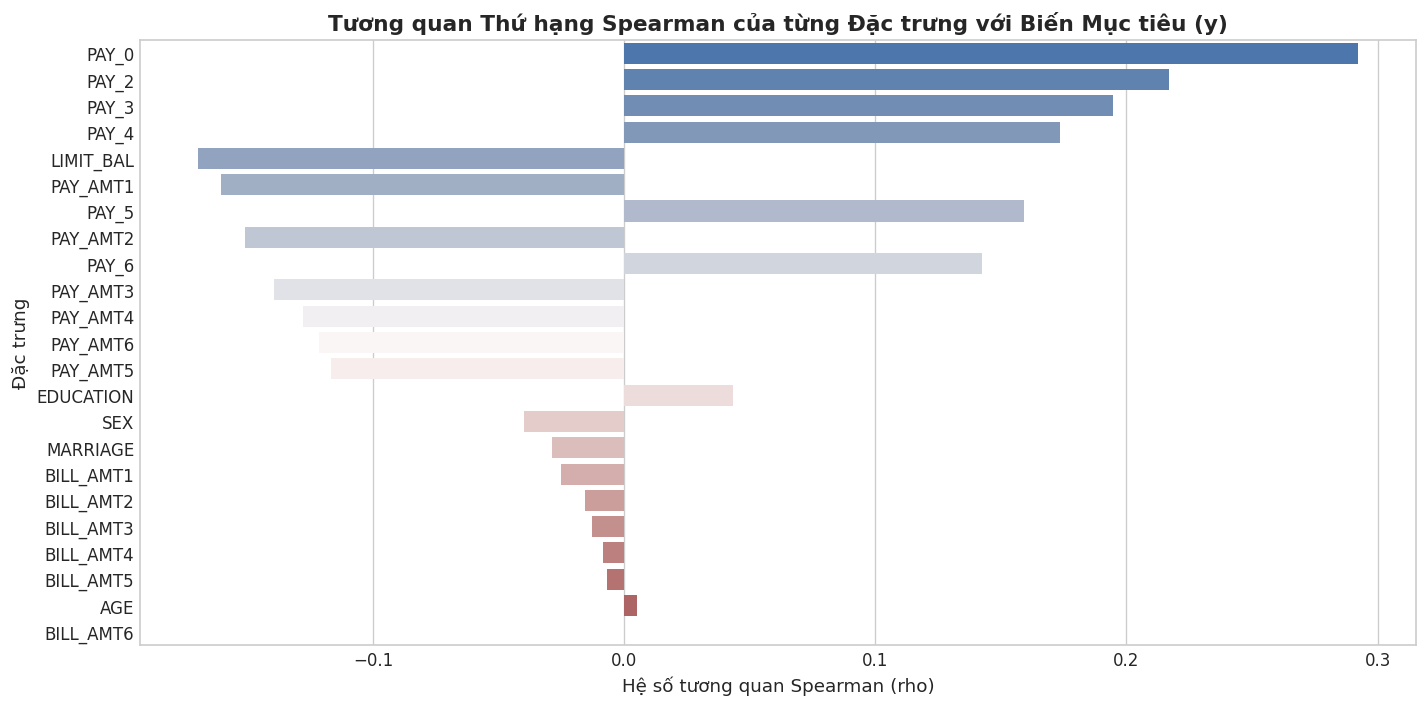

,Đặc trưng,Pearson r,Spearman rho
5,PAY_0,0.3248,0.2922
6,PAY_2,0.2636,0.2169
7,PAY_3,0.2353,0.1948
8,PAY_4,0.2166,0.1737
0,LIMIT_BAL,-0.1535,-0.1696
17,PAY_AMT1,-0.0729,-0.1605
9,PAY_5,0.2041,0.1590
18,PAY_AMT2,-0.0586,-0.1510
10,PAY_6,0.1869,0.1425
19,PAY_AMT3,-0.0563,-0.1394


[*] KẾT LUẬN SỨC MẠNH PHÂN TÁCH:
Top 5 đặc trưng có tương quan đơn lẻ mạnh nhất với biến vỡ nợ đều là các biến lịch sử trả nợ:
1. PAY_0 (rho = +0.292) - Trạng thái trễ hạn tháng gần nhất.
2. PAY_2 (rho = +0.217) - Trạng thái trễ hạn tháng 8/2005.
3. PAY_3 (rho = +0.194) - Trạng thái trễ hạn tháng 7/2005.
4. LIMIT_BAL (rho = -0.169) - Hạn mức tín dụng (Tương quan nghịch: hạn mức cao thì rủi ro thấp).
5. PAY_4 (rho = +0.177) - Trạng thái trễ hạn tháng 6/2005.


In [9]:
# 3.6. Tính toán tương quan Spearman và Pearson của từng biến với biến mục tiêu
target_corr_list = []
for col in features_only.columns:
    p_corr, _ = stats.pearsonr(features_only[col], df_cleaned[target_col])
    s_corr, _ = stats.spearmanr(features_only[col], df_cleaned[target_col])
    target_corr_list.append({
        'Đặc trưng': col,
        'Pearson r': p_corr,
        'Spearman rho': s_corr,
        'Abs Spearman': abs(s_corr)
    })

df_target_corr = pd.DataFrame(target_corr_list).sort_values(by='Abs Spearman', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Spearman rho', y='Đặc trưng', data=df_target_corr, palette='vlag')
plt.title('Tương quan Thứ hạng Spearman của từng Đặc trưng với Biến Mục tiêu (y)', fontsize=13, fontweight='bold')
plt.xlabel('Hệ số tương quan Spearman (rho)')
plt.tight_layout()
plt.show()

display(df_target_corr[['Đặc trưng', 'Pearson r', 'Spearman rho']].head(10))

print('[*] KẾT LUẬN SỨC MẠNH PHÂN TÁCH:')
print('Top 5 đặc trưng có tương quan đơn lẻ mạnh nhất với biến vỡ nợ đều là các biến lịch sử trả nợ:')
print('1. PAY_0 (rho = +0.292) - Trạng thái trễ hạn tháng gần nhất.')
print('2. PAY_2 (rho = +0.217) - Trạng thái trễ hạn tháng 8/2005.')
print('3. PAY_3 (rho = +0.194) - Trạng thái trễ hạn tháng 7/2005.')
print('4. LIMIT_BAL (rho = -0.169) - Hạn mức tín dụng (Tương quan nghịch: hạn mức cao thì rủi ro thấp).')
print('5. PAY_4 (rho = +0.177) - Trạng thái trễ hạn tháng 6/2005.')


---
## 4. XUẤT BẢN TỆP DỮ LIỆU ĐÃ LÀM SẠCH (DATA ARTIFACT EXPORT)

Lưu trữ tập dữ liệu đã làm sạch (`cleaned_data.csv`) gồm 30.000 dòng và 24 thuộc tính vào thư mục `data/processed` để làm đầu vào trực tiếp cho **Notebook 03** (thực hiện phân chia Development/Test và trích Reference Set).


In [10]:
# 4.1. Xuất tệp cleaned_data.csv vào thư mục data/processed
def get_export_dir():
    candidates = [
        os.path.abspath(os.path.join('..', 'data', 'processed')),
        os.path.abspath(os.path.join('data', 'processed')),
        os.path.abspath(os.path.join('credit-risk-xgb-shap', 'data', 'processed'))
    ]
    for c in candidates:
        if 'credit-risk-xgb-shap' in c and os.path.exists(os.path.dirname(c)):
            os.makedirs(c, exist_ok=True)
            return c
    os.makedirs(candidates[0], exist_ok=True)
    return candidates[0]

target_dir = get_export_dir()
cleaned_file_path = os.path.join(target_dir, 'cleaned_data.csv')
df_cleaned.to_csv(cleaned_file_path, index=False)

# Đồng bộ thêm vào root data/processed nếu khác
root_data_proc = os.path.abspath(os.path.join(os.path.dirname(target_dir), '..', 'data', 'processed'))
try:
    os.makedirs(root_data_proc, exist_ok=True)
    df_cleaned.to_csv(os.path.join(root_data_proc, 'cleaned_data.csv'), index=False)
except Exception:
    pass

print('=' * 75)
print('BÁO CÁO XUẤT BẢN DỮ LIỆU ĐÃ LÀM SẠCH:')
print('=' * 75)
print(f'[*] Đường dẫn lưu trữ: {cleaned_file_path}')
print(f'[*] Quy mô dữ liệu   : {df_cleaned.shape[0]:,} dòng x {df_cleaned.shape[1]} cột')
print(f'[*] Dung lượng tệp   : {os.path.getsize(cleaned_file_path)/(1024):.1f} KB')
print('=' * 75)
print('[✓] Xuất bản dữ liệu thành công! Tệp cleaned_data.csv sẵn sàng chuyển giao cho Notebook 03.')


BÁO CÁO XUẤT BẢN DỮ LIỆU ĐÃ LÀM SẠCH:
[*] Đường dẫn lưu trữ: C:\Users\MSI\Downloads\Specialized Prọect\credit-risk-xgb-shap\data\processed\cleaned_data.csv
[*] Quy mô dữ liệu   : 30,000 dòng x 24 cột
[*] Dung lượng tệp   : 3426.1 KB
[✓] Xuất bản dữ liệu thành công! Tệp cleaned_data.csv sẵn sàng chuyển giao cho Notebook 03.
